In [2]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd


In [3]:
voltage = [8.36,8.28,8.23,8.16,8.1,7.97,7.89,7.83,7.78,7.71]
distance = []
voltage_60 = [8.34,8,7.8,7.6,7.4,7.2,7,6.8,6.6,6.4]
length = 5.4
cutoff = 7.11
step = 5
for i in range(0,len(voltage)):
    distance.append(i*step*length)

In [4]:
voltage = np.array(voltage)
distance = np.array(distance)
a,b = np.polyfit(distance,voltage,1)

a_60,b_60 = np.polyfit(distance,voltage_60,1)

In [5]:
max_distance = (cutoff-b)/a
max_distance_60 = (cutoff-b_60)/a_60
print(max_distance)
print(max_distance_60)
distance = np.append(distance,max_distance)
voltage = np.append(voltage,cutoff)

455.3531326281565
148.02714535901922


In [6]:
print(distance)

[  0.          27.          54.          81.         108.
 135.         162.         189.         216.         243.
 455.35313263]


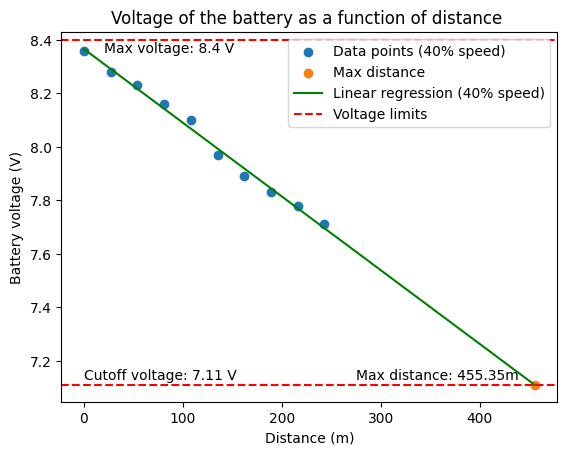

In [7]:
#Plot the distance vs voltage
plt.scatter(distance[:-1],voltage[:-1])
plt.xlabel('Distance (m)')
plt.ylabel('Battery voltage (V)')
plt.title('Voltage of the battery as a function of distance ')
plt.scatter(max_distance,cutoff)
#Plot the cutoff voltage
plt.plot(distance, a*distance + b, color='g')
plt.axhline(y=8.4, color='r', linestyle='--')
plt.axhline(y=cutoff, color='r', linestyle='--')
plt.text(max_distance -180, cutoff+0.02, 'Max distance: {:.2f}m'.format(max_distance))
plt.text(0,cutoff+0.02, 'Cutoff voltage: 7.11 V')
plt.text(20,8.35, 'Max voltage: 8.4 V')
plt.legend(['Data points (40% speed)','Max distance','Linear regression (40% speed)','Voltage limits'])
plt.show()
